In [2]:
import os
import paths
import pandas as pd
import geopandas as gpd

from tqdm import tqdm

import train_model.train as train
from apollo import metrics as me
from apollo import osgconv as osg

from shapely.geometry import Point


In [3]:
metadata = pd.read_csv(paths.DATA + '/nrfa-station-metadata.csv')

In [4]:
# Get list of station IDs from subfolder names
station_ids = [folder for folder in os.listdir(paths.CATCHMENT_BASINS) if os.path.isdir(os.path.join(paths.CATCHMENT_BASINS, folder))]

# Convert IDs to appropriate type (e.g., int or str) to match df['id'] format
# Assuming 'id' in df is numeric, convert folder names to int
station_ids = [int(id_str) for id_str in station_ids if id_str.isdigit()]

# Filter the DataFrame
metadata_df = metadata[metadata['id'].isin(station_ids)]

In [5]:
metadata_df

,id,name,catchment-area,easting,northing,latitude,longitude,river,location,station-level,...,mean-flood-plain-depth,mean-flood-plain-location,mean-flood-plain-extent,urbext-1990,urbconc-1990,urbloc-1990,urbext-2000,urbconc-2000,urbloc-2000,data-summary
1,2001,Helmsdale at Kilphedir,551.4,299839.0,918163.0,58.14100,-3.70295,Helmsdale,Kilphedir,17.0,...,0.671,1.069,0.0555,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
4,3002,Carron at Sgodachail,241.1,249136.0,892152.0,57.89321,-4.54668,Carron,Sgodachail,70.7,...,0.633,0.863,0.0377,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
5,3003,Oykel at Easter Turnaig,330.7,240305.0,900145.0,57.96185,-4.70086,Oykel,Easter Turnaig,15.6,...,0.750,0.920,0.0488,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
6,3004,Cassley at Rosehall,187.5,247176.0,902133.0,57.98210,-4.58615,Cassley,Rosehall,3.3,...,0.954,0.962,0.0557,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d
9,4001,Conon at Moy Bridge,961.8,248129.0,854675.0,57.55658,-4.53997,Conon,Moy Bridge,10.0,...,0.885,0.868,0.0470,0.0002,NaN,NaN,0.0001,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,205005,Ravernet at Ravernet,73.5,326651.0,361265.0,54.48403,-6.04659,Ravernet,Ravernet,31.0,...,0.893,1.046,0.1065,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
1586,205008,Lagan at Drumiller,84.6,323635.0,352493.0,54.40601,-6.09675,Lagan,Drumiller,81.0,...,0.668,0.750,0.0694,0.0135,NaN,0.747,0.0013,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
1588,205011,Annacloy at Kilmore Bridge,186.6,344853.0,350808.0,54.38530,-5.77106,Annacloy,Kilmore Bridge,9.0,...,0.894,0.933,0.1041,0.0235,NaN,0.941,0.0113,0.741,0.898,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
1595,206001,Clanrye at Mountmill Bridge,120.3,308536.0,331026.0,54.21668,-6.33695,Clanrye,Mountmill Bridge,16.0,...,0.513,0.901,0.0640,0.0095,NaN,1.071,0.0036,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...


In [6]:
# Initialize list to collect geometries
geometries = []

# Loop over each row in metadata_df
for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
    station_id = str(row['id'])
    shapefile_path = os.path.join(paths.CATCHMENT_BASINS, station_id, f"{station_id}.shp")
    
    if os.path.exists(shapefile_path):
        gdf = gpd.read_file(shapefile_path)
        # Assuming the shapefile contains one geometry (e.g., a polygon)
        geom = gdf.geometry.values[0]
    else:
        geom = None  # If shapefile is missing, store None

    geometries.append(geom)

# Add geometry to metadata_df
metadata_df['geometry'] = geometries

# Convert to GeoDataFrame
metadata_gdf = gpd.GeoDataFrame(metadata_df, geometry='geometry', crs="EPSG:27700")  # or update CRS as needed


100%|██████████| 899/899 [05:39<00:00,  2.65it/s]
/var/folders/zx/t4x2p2md0y3_5gs01s3cq2gm0000gq/T/ipykernel_4284/897788732.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_df['geometry'] = geometries


In [7]:
output_path = os.path.join(paths.DATA, 'nrfa-station-metadata-gdf.csv')
metadata_gdf.to_csv(output_path, index=False)

In [8]:
def find_longest_diagonal(polygon):
    """
    Returns the longest edge of the polygon's minimum rotated rectangle.
    """
    if polygon is None or polygon.is_empty:
        print('polygon is empty')
        return float('nan')  # or None if preferred
    
    box = polygon.minimum_rotated_rectangle
    x, y = box.exterior.coords.xy
    edge1 = Point(x[0], y[0]).distance(Point(x[1], y[1]))
    edge2 = Point(x[1], y[1]).distance(Point(x[2], y[2]))
    return max(edge1, edge2)

In [9]:
# 1. Compute latitude from centroid (if not already in dataframe)
def calculate_latitude(geometry):
    centroid = geometry.centroid
    lat, lon = osg.BNG_2_latlon(centroid.x, centroid.y)
    return lat

In [10]:
# 1. Compute the cross-sectional distance
metadata_gdf['cross_distance'] = metadata_gdf['geometry'].apply(find_longest_diagonal)

# 2. Merge 10th and 90th percentile altitude data from metadata_df
metadata_gdf = metadata_gdf.merge(
    metadata_df[['id', '10-percentile-altitude', '90-percentile-altitude', '50-percentile-altitude']],
    on='id',
    how='left'
)

/Users/av656/anaconda3/envs/sf_env/lib/python3.10/site-packages/shapely/constructive.py:1353: RuntimeWarning: invalid value encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)
/Users/av656/anaconda3/envs/sf_env/lib/python3.10/site-packages/shapely/constructive.py:1353: RuntimeWarning: divide by zero encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)


In [11]:
# 3. Compute height difference and slope gradient
metadata_gdf['height_difference'] = metadata_gdf['90-percentile-altitude_x'] - metadata_gdf['10-percentile-altitude_x']
metadata_gdf['slope_gradient'] = metadata_gdf['height_difference'] / metadata_gdf['cross_distance']
metadata_gdf['slope_gradient_^1/2'] = metadata_gdf['slope_gradient']**(1/2)

In [12]:
metadata_gdf['area_^1/2'] = metadata_gdf['catchment-area']**(1/2)

In [13]:
metadata_gdf['latitude'] = metadata_gdf['geometry'].apply(calculate_latitude)

In [14]:
metadata_gdf['median altitude'] = metadata_gdf['50-percentile-altitude_x']

In [15]:
# Find rows with missing (None) geometry
null_geom_rows = metadata_gdf[metadata_gdf['geometry'].isnull()]
print("Rows with None geometry:")
print(null_geom_rows[['id', 'geometry']])

Rows with None geometry:
Empty GeoDataFrame
Columns: [id, geometry]
Index: []


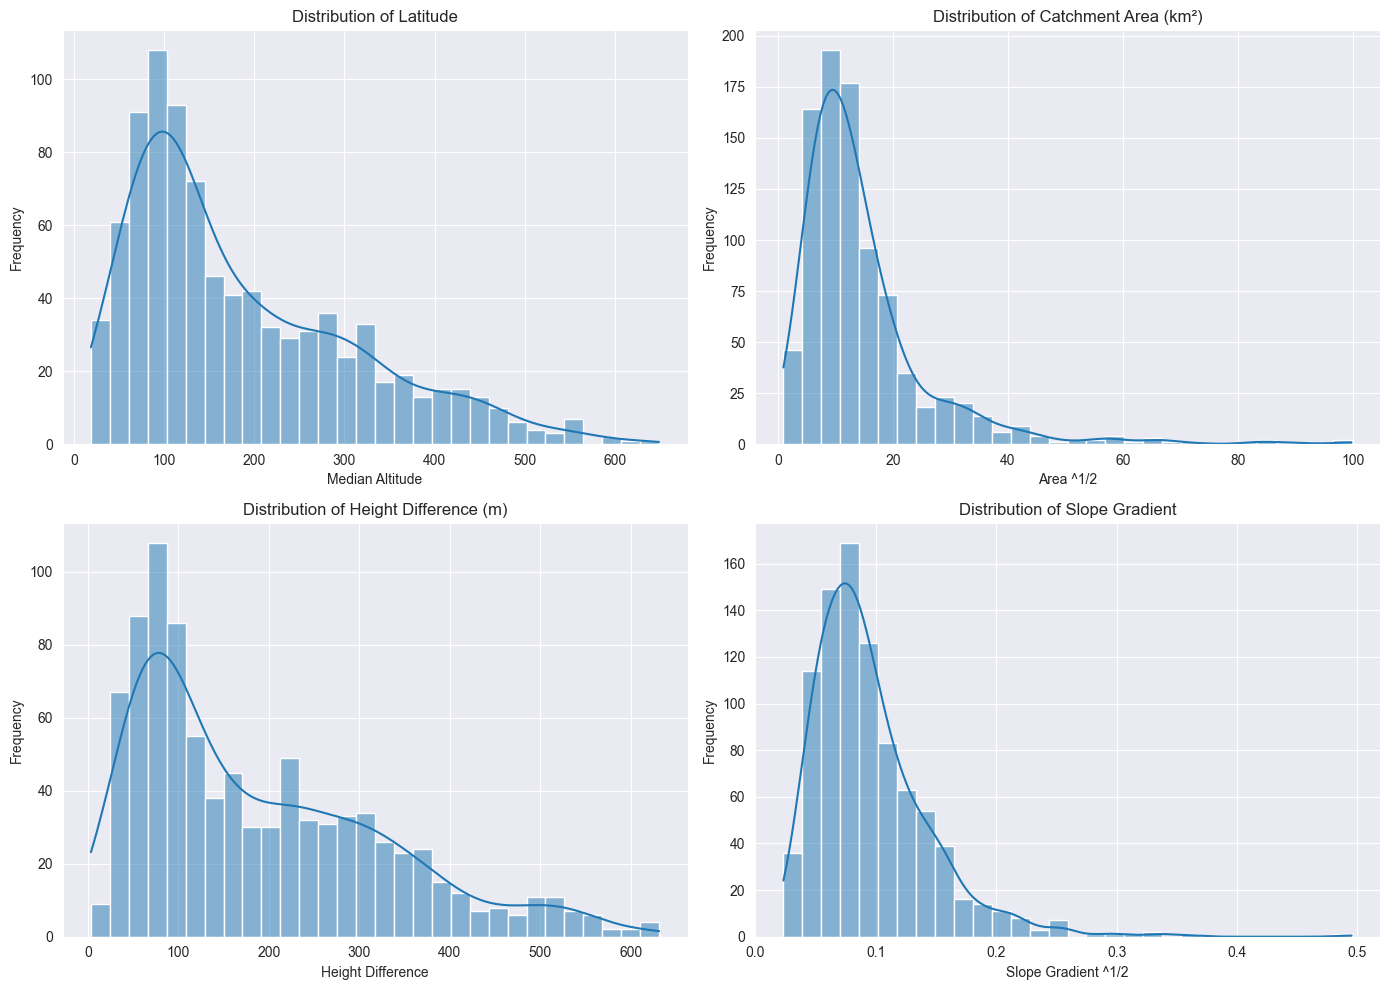

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point

# Add latitude column if missing
if 'latitude' not in metadata_gdf.columns:
    metadata_gdf['latitude'] = metadata_gdf['geometry'].apply(calculate_latitude)

# 2. Drop NaNs from relevant columns
plot_df = metadata_gdf[['median altitude', 'area_^1/2', 'height_difference', 'slope_gradient_^1/2']].dropna()

# 3. Create 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define plot settings
plot_vars = ['median altitude', 'area_^1/2', 'height_difference', 'slope_gradient_^1/2']
titles = ['Distribution of Latitude', 'Distribution of Catchment Area (km²)', 
          'Distribution of Height Difference (m)', 'Distribution of Slope Gradient']

# 4. Plot
for ax, var, title in zip(axes, plot_vars, titles):
    sns.histplot(plot_df[var], bins=30, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.grid(True)

plt.tight_layout()
plt.show()


In [17]:
days = 6

years_train = [1980 + i for i in range(30)]
years_eval = [2010 + i for i in range(10)]

features = (['Rain'] + ['Rain-' + f'{d+1}' for d in range(days)] 
            + ['Temperature'] + ['Temperature-' + f'{d+1}' for d in range(days)] \
            + ['Resultant Windspeed'] + ['Resultant Windspeed-' + f'{d+1}' for d in range(days)] \
            + ['Humidity'] + ['Humidity-' + f'{d+1}' for d in range(days)]\
            #+ ['Soil Moisture ' + f'{i+1}' for i in range(4)])
            + ['Rain_28_Mu','Rain_90_Mu','Rain_180_Mu', 'Temperature_28_Mu','Temperature_90_Mu','Temperature_180_Mu']) 

In [33]:
input_type = 'nrfa'

performance = []

for station_nr in os.listdir(paths.DATA + '/predictions/nrfa'):
    
    print(station_nr)
    
    if station_nr == '.DS_Store':
        continue
    
    station_nr = station_nr.split("_")[0]

    df = pd.read_csv(paths.CATCHMENT_BASINS + '/' + str(station_nr) + '/' + str(str(station_nr)) + '.csv')
    name = df.loc[df.index[3]].iloc[2]

    boundary = gpd.read_file \
        (paths.CATCHMENT_BASINS + '/' + str(station_nr) + '/' + str(str(station_nr) + '.shp'))

    df_predictions = pd.read_csv(paths.PREDICTIONS + f"/{input_type}/{station_nr}_{input_type}.csv")
    df_predictions = df_predictions.dropna(subset=['Flow', 'Predicted'])
    df_predictions = df_predictions.loc[:, ~df_predictions.columns.str.contains('^Unnamed')]
    try:
        df_predictions['Date'] = pd.to_datetime(df_predictions['Date'], format='%Y-%m-%d %H:%M:%S').dt.normalize()
    except ValueError:
        df_predictions['Date'] = pd.to_datetime(df_predictions['Date'], format='%Y-%m-%d').dt.normalize()

    df_test = df_predictions[df_predictions['Date'].dt.year.isin(years_eval)]
    NSE = me.R2(df_test['Flow'], df_test['Predicted'])
    HE_mean = ((df_test['Flow'].mean( ) /boundary.geometry.area ) *((10 ^6) ) *86400000).iloc[0]

    performance.append({
            'Station': station_nr,
            'NSE': NSE,
            'HE_mean': HE_mean,
        })

    overview_gdf = gpd.GeoDataFrame(performance)

60002_nrfa.csv
60003_nrfa.csv
205011_nrfa.csv
84020_nrfa.csv
47009_nrfa.csv
69041_nrfa.csv
47008_nrfa.csv
27069_nrfa.csv
23001_nrfa.csv
10002_nrfa.csv
76004_nrfa.csv
76005_nrfa.csv
39010_nrfa.csv
37009_nrfa.csv
33061_nrfa.csv
37008_nrfa.csv
39011_nrfa.csv
80001_nrfa.csv
67010_nrfa.csv
69008_nrfa.csv
54012_nrfa.csv
33028_nrfa.csv
41027_nrfa.csv
33029_nrfa.csv
39058_nrfa.csv
58005_nrfa.csv
42014_nrfa.csv
54080_nrfa.csv
27021_nrfa.csv
54081_nrfa.csv
11001_nrfa.csv
22003_nrfa.csv
28072_nrfa.csv
44004_nrfa.csv
38012_nrfa.csv
4003_nrfa.csv
52003_nrfa.csv
34004_nrfa.csv
34005_nrfa.csv
27056_nrfa.csv
27057_nrfa.csv
25011_nrfa.csv
40024_nrfa.csv
43017_nrfa.csv
81003_nrfa.csv
81002_nrfa.csv
41019_nrfa.csv
30011_nrfa.csv
55025_nrfa.csv
33022_nrfa.csv
39053_nrfa.csv
33023_nrfa.csv
39052_nrfa.csv
40011_nrfa.csv
40010_nrfa.csv
73013_nrfa.csv
69002_nrfa.csv
54018_nrfa.csv
54019_nrfa.csv
37003_nrfa.csv
27062_nrfa.csv
27063_nrfa.csv
74001_nrfa.csv
28047_nrfa.csv
28046_nrfa.csv
7004_nrfa.csv
7005_nrfa.c

In [34]:
import os
import pandas as pd
import geopandas as gpd
from typing import List
from tqdm import tqdm

def evaluate_model_performance(
    data_source: str,
    input_type: str,
    years_eval: List[int],
    paths,
    metric_function,  # e.g., me.R2
) -> gpd.GeoDataFrame:
    """
    Evaluate NSE and HE_mean for each NRFA station and return a GeoDataFrame.

    Parameters:
        input_type (str): e.g., '_9to9'
        years_eval (List[int]): years to filter predictions on
        paths (Namespace or dict): must include paths.DATA, paths.CATCHMENT_BASINS, paths.PREDICTIONS
        metric_function (callable): function to compute NSE, e.g., me.R2

    Returns:
        GeoDataFrame: with columns ['Station', 'NSE', 'HE_mean', 'geometry']
    """
    
    performance_records = []

    station_dirs = os.listdir(os.path.join(paths.DATA, 'predictions', 'nrfa_run4'))

    for station_nr in tqdm(station_dirs, desc="Evaluating stations"):
        
        station_nr = station_nr.split('_')[0]
        
        try:
            # Read catchment boundary
            shp_path = os.path.join(paths.CATCHMENT_BASINS, station_nr, f"{station_nr}.shp")
            boundary = gpd.read_file(shp_path)

            # Read prediction file
            pred_path = os.path.join(paths.PREDICTIONS, data_source, f"{station_nr}_{data_source}.csv")
            df_predictions = pd.read_csv(pred_path)

            df_predictions["Date"] = pd.to_datetime(df_predictions["Date"], errors="coerce")
            HE_mean = ((df_predictions['Flow'].mean() / boundary.geometry.area) * (10**6) * 86400000).iloc[0]
            
            metrics = train.calculate_performance_metrics(df_predictions, years_eval, plot=False)

            performance_records.append({
                'Station': station_nr,
                'RE': metrics.get("RE"),
                'NSE': metrics.get("NSE"),
                'KGE': metrics.get("KGE"),
                'HE_mean': HE_mean,
                'geometry': boundary.geometry.iloc[0]
            })

        except Exception as e:
            print(f"Skipping station {station_nr} due to error: {e}")
            continue

    overview_gdf = gpd.GeoDataFrame(performance_records, geometry='geometry')
    return overview_gdf

In [35]:
years_eval = list(range(2010, 2021)) 

In [36]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [22]:
overview_gdf_nrfa = evaluate_model_performance(
    data_source='nrfa',
    input_type='9to9',
    years_eval=years_eval,
    paths=paths,
    metric_function=me.R2
)
#overview_gdf_nrfa.to_csv(paths.PREDICTIONS + '/results/nrfa_original.csv')

Evaluating stations:  15%|█▌        | 135/900 [01:31<06:28,  1.97it/s]

Skipping station .DS due to error: /Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/.DS/.DS.shp: No such file or directory


Evaluating stations: 100%|██████████| 900/900 [10:05<00:00,  1.49it/s]


In [129]:
overview_gdf_era5 = evaluate_model_performance(
    data_source='era5',
    input_type='9to9',
    years_eval=years_eval,
    paths=paths,
    metric_function=me.R2
)
#overview_gdf_era5.to_csv(paths.PREDICTIONS + '/results/era5_original.csv')

Evaluating stations:  22%|██▏       | 7/32 [00:02<00:07,  3.26it/s]

Skipping station .DS due to error: /Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/.DS/.DS.shp: No such file or directory


Evaluating stations: 100%|██████████| 32/32 [00:53<00:00,  1.66s/it]


In [23]:
overview_gdf_nrfa_run3 = evaluate_model_performance(
    data_source='nrfa_run3',
    input_type='9to9',
    years_eval=years_eval,
    paths=paths,
    metric_function=me.R2
)
#overview_gdf_nrfa_run3.to_csv(paths.PREDICTIONS + '/results/nrfa_improved_model.csv')

Evaluating stations:  15%|█▌        | 135/900 [01:32<06:39,  1.91it/s]

Skipping station .DS due to error: /Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/.DS/.DS.shp: No such file or directory


Evaluating stations:  83%|████████▎ | 747/900 [08:27<02:12,  1.16it/s]

Skipping station 24001 due to error: division by zero


Evaluating stations: 100%|██████████| 900/900 [10:31<00:00,  1.43it/s]


In [42]:
overview_gdf_era5_run3 = evaluate_model_performance(
    data_source='era5_run3',
    input_type='9to9',
    years_eval=years_eval,
    paths=paths,
    metric_function=me.R2
)
#overview_gdf_era5_run3.to_csv(paths.PREDICTIONS + '/results/era5_improved_model.csv')

Evaluating stations:  15%|█▌        | 135/900 [02:25<14:12,  1.11s/it]

Skipping station .DS due to error: /Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/.DS/.DS.shp: No such file or directory


Evaluating stations:  83%|████████▎ | 746/900 [13:43<02:54,  1.14s/it]

Skipping station 24001 due to error: division by zero


Evaluating stations: 100%|██████████| 900/900 [16:50<00:00,  1.12s/it]


In [25]:
overview_gdf_nrfa_run4 = evaluate_model_performance(
    data_source='nrfa_run4',
    input_type='9to9',
    years_eval=years_eval,
    paths=paths,
    metric_function=me.R2
)

Evaluating stations:  15%|█▌        | 135/900 [01:07<09:03,  1.41it/s]

Skipping station .DS due to error: /Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/.DS/.DS.shp: No such file or directory


Evaluating stations:  83%|████████▎ | 748/900 [06:39<00:43,  3.47it/s]

Skipping station 24001 due to error: division by zero


Evaluating stations: 100%|██████████| 900/900 [07:58<00:00,  1.88it/s]


In [41]:
overview_gdf_era5_run4 = evaluate_model_performance(
    data_source='era5_run4',
    input_type='9to9',
    years_eval=years_eval,
    paths=paths,
    metric_function=me.R2
)

Evaluating stations:  15%|█▌        | 135/900 [02:25<11:31,  1.11it/s]

Skipping station .DS due to error: /Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/.DS/.DS.shp: No such file or directory


Evaluating stations:  83%|████████▎ | 746/900 [13:55<01:51,  1.38it/s]

Skipping station 24001 due to error: division by zero


Evaluating stations: 100%|██████████| 900/900 [16:53<00:00,  1.13s/it]


In [45]:
metadata_gdf = metadata_gdf.rename(columns={'id': 'Station'})

In [61]:
gdf_nrfa = pd.read_csv(paths.PREDICTIONS + '/results/nrfa_original.csv')
gdf_era5 = pd.read_csv(paths.PREDICTIONS + '/results/era5_original.csv')
gdf_nrfa_improved = pd.read_csv(paths.PREDICTIONS + '/results/nrfa_improved_model.csv')
gdf_era5_improved = pd.read_csv(paths.PREDICTIONS + '/results/era5_improved_model.csv')

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_vertical_nse_diff(
    gdf_run2: pd.DataFrame,
    gdf_run3: pd.DataFrame,
    metadata: pd.DataFrame,
    variable: str,
    key: str = "Station",
    nse_col: str = "NSE",
    label1: str = "ERA5 Run2",
    label2: str = "ERA5 Run3",
    jitter: float = 0.0,   # small x-jitter to reduce overlap if needed (e.g., 0.02)
):
    # Ensure merge key has same dtype everywhere
    for df in (gdf_run2, gdf_run3, metadata):
        df[key] = df[key].astype(str)

    df2 = gdf_run2[[key, nse_col]].rename(columns={nse_col: f"{nse_col}_run2"})
    df3 = gdf_run3[[key, nse_col]].rename(columns={nse_col: f"{nse_col}_run3"})
    meta = metadata[[key, variable]]

    m = meta.merge(df2, on=key, how="inner").merge(df3, on=key, how="inner")
    m = m.dropna(subset=[variable, f"{nse_col}_run2", f"{nse_col}_run3"])

    x = m[variable].to_numpy(dtype=float)
    y1 = m[f"{nse_col}_run2"].to_numpy(dtype=float)
    y2 = m[f"{nse_col}_run3"].to_numpy(dtype=float)

    if jitter:
        x = x + np.random.uniform(-jitter, jitter, size=x.shape)

    fig, ax = plt.subplots()
    # Endpoints
    ax.scatter(x, y1, s=8, color="green", label=label1)  # smaller & green
    ax.scatter(x, y2, s=8, color="red", label=label2)    # smaller & red

    # Optional vertical connectors
    # for xi, yi1, yi2 in zip(x, y1, y2):
    #     ax.vlines(xi, yi1, yi2, alpha=0.5)

    ax.set_xlabel(variable)
    ax.set_ylabel(nse_col)
    ax.set_title(f"{nse_col} ({label1} vs {label2})")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


In [39]:
metadata_gdf = metadata_gdf.rename(columns={'id': 'Station'})

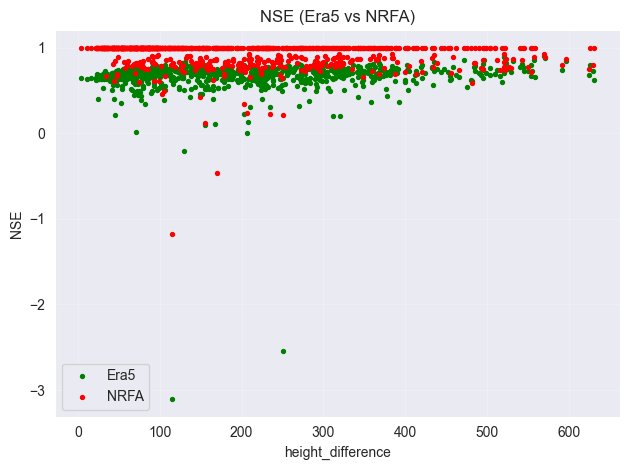

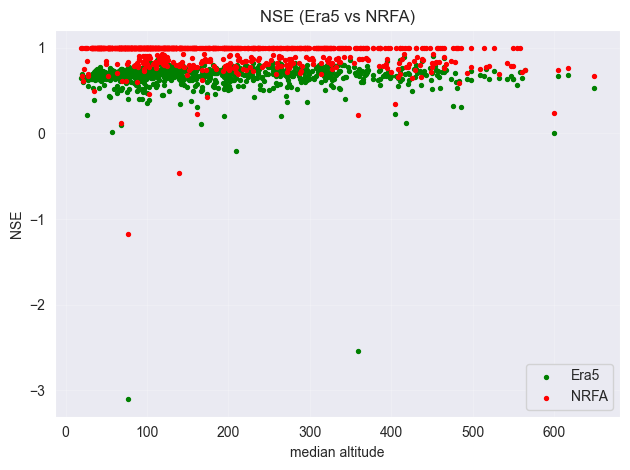

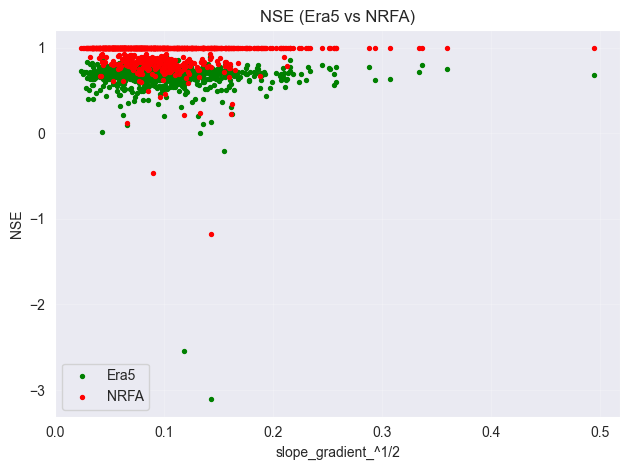

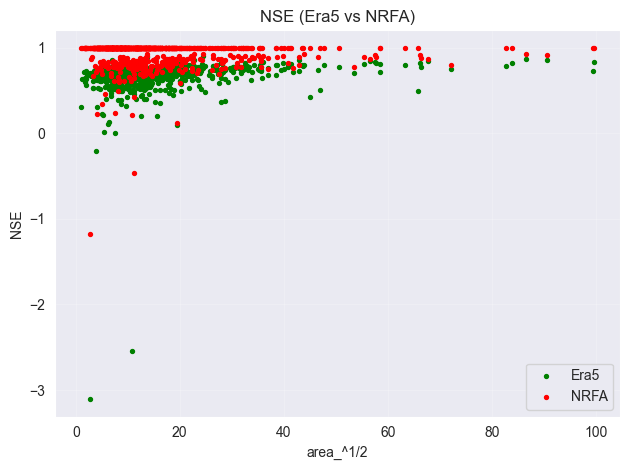

In [65]:
variables = ['height_difference', 'median altitude', 'slope_gradient_^1/2', 'area_^1/2']

for var in variables:
    plot_vertical_nse_diff(
        overview_gdf_era5_run4,
        overview_gdf_nrfa_run4,
        metadata_gdf,
        nse_col="NSE",
        variable=var,
        label1='Era5',
        label2='NRFA'
    )

In [60]:
import folium

def plot_low_nse_folium(metadata_gdf, nse_df, center, key="station", nse_col="NSE", threshold=0.4):
    # Ensure join key type is consistent
    metadata_gdf = metadata_gdf.copy()
    nse_df = nse_df.copy()
    metadata_gdf[key] = metadata_gdf[key].astype(str)
    nse_df[key] = nse_df[key].astype(str)

    # Merge NSE values into geometry GDF
    g = metadata_gdf.merge(nse_df[[key, nse_col]], on=key, how="left")

    # Filter
    g_low = g[g[nse_col].notna() & (g[nse_col] < threshold)]
    print(g_low)

    # Create folium map
    uk_coords = [54.5, -3.5]
    m = folium.Map(location=uk_coords, zoom_start=5)
    folium.TileLayer('CartoDB Positron No Labels').add_to(m)

    # Add low NSE catchments as GeoJSON with popups
    folium.GeoJson(
        g_low,
        name="Low NSE Catchments",
        style_function=lambda feature: {
            "fillColor": "red",
            "color": "black",
            "weight": 1,
            "fillOpacity": 0.6,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[key, nse_col],
            aliases=["Station", "NSE"],
            localize=True
        )
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m, g_low

# Example usage:
m, g_low = plot_low_nse_folium(metadata_gdf, overview_gdf_era5_run4, center=[9.0, 8.0], key="Station", nse_col="NSE", threshold=0.4)
# m.save("low_nse_map.html")


    Station                           name  catchment-area   easting  \
35    12009          Water of Dye at Charr           41.70  362411.0   
67    19010         Braid Burn at Liberton           16.20  327249.0   
102   23002        Derwent at Eddys Bridge          118.00  404107.0   
106   23007       Derwent at Rowlands Gill          242.10  416815.0   
125   25019                 Leven at Easby           14.80  458466.0   
128   25023    Tees at Cow Green Reservoir           58.20  381394.0   
129   26002         Hull at Hempholme Lock          378.10  507957.0   
140   27022  Don at Rotherham Forge Island          826.00  442682.0   
152   27038       Costa Beck at Gatehouses            7.80  477405.0   
172   27063     Dibb at Grimwith Reservoir           25.50  405777.0   
206   28049               Ryton at Worksop           77.00  457520.0   
227   29005           Rase at Bishopbridge           66.60  503210.0   
228   29009        Ancholme at Toft Newton           27.20  5032

In [64]:
g_low.to_csv(paths.PREDICTIONS + '/results/catchments_with_NSE_below_0.4_era5.csv')

In [69]:
# stations you want to exclude
exclude = [23002, 25023, 26002, 27063]              # put your numbers here
exclude = {str(x) for x in exclude}   # compare as strings

g_low_adjusted = g_low[~g_low["Station"].astype(str).str.strip().isin(exclude)].copy()

In [71]:
g_low_adjusted.to_csv(paths.PREDICTIONS + '/results/catchments_with_NSE_below_0.4_era5.csv')

In [72]:
g_low_adjusted

,Station,name,catchment-area,easting,northing,latitude,longitude,river,location,station-level,...,cross_distance,10-percentile-altitude_y,90-percentile-altitude_y,50-percentile-altitude_y,height_difference,slope_gradient,slope_gradient_^1/2,area_^1/2,median altitude,NSE
35,12009,Water of Dye at Charr,41.70,362411.0,783457.0,56.457057,-2.61940,Water of Dye,Charr,239.0,...,10173.588008,321.2,529.2,417.9,208.0,0.020445,0.142986,6.457554,417.9,0.127695
67,19010,Braid Burn at Liberton,16.20,327249.0,670781.0,55.902482,-3.16579,Braid Burn,Liberton,49.9,...,9022.288721,100.7,335.7,161.5,235.0,0.026047,0.161390,4.024922,161.5,0.308852
106,23007,Derwent at Rowlands Gill,242.10,416815.0,558094.0,54.855371,-1.73921,Derwent,Rowlands Gill,26.2,...,32470.754325,129.5,450.4,264.9,320.9,0.009883,0.099412,15.559563,264.9,0.198218
125,25019,Leven at Easby,14.80,458466.0,508686.0,54.478513,-1.09939,Leven,Easby,101.3,...,5395.656300,155.4,285.3,209.7,129.9,0.024075,0.155161,3.847077,209.7,-0.203873
140,27022,Don at Rotherham Forge Island,826.00,442682.0,392768.0,53.356881,-1.35908,Don,Rotherham Forge Island,23.2,...,54157.566415,68.1,350.5,153.7,282.4,0.005214,0.072211,28.740216,153.7,0.373894
152,27038,Costa Beck at Gatehouses,7.80,477405.0,483621.0,54.263476,-0.81373,Costa Beck,Gatehouses,21.9,...,5599.759952,28.4,143.1,77.0,114.7,0.020483,0.143119,2.792848,77.0,-3.105325
206,28049,Ryton at Worksop,77.00,457520.0,379490.0,53.330061,-1.13820,Ryton,Worksop,32.1,...,12016.629185,52.6,130.2,102.4,77.6,0.006458,0.080360,8.774964,102.4,0.389210
227,29005,Rase at Bishopbridge,66.60,503210.0,391180.0,53.394324,-0.44889,Rase,Bishopbridge,4.1,...,14538.585079,15.1,120.4,34.8,105.3,0.007243,0.085105,8.160882,34.8,0.394119
228,29009,Ancholme at Toft Newton,27.20,503210.0,387470.0,53.358478,-0.45010,Ancholme,Toft Newton,7.7,...,11616.944637,13.8,58.6,26.0,44.8,0.003856,0.062100,5.215362,26.0,0.217875
543,47010,Tamar at Crowford Bridge,76.70,229006.0,99099.0,50.650685,-4.42614,Tamar,Crowford Bridge,84.0,...,9289.626870,109.1,191.3,140.0,82.2,0.008849,0.094067,8.757854,140.0,0.342319


In [79]:
from pathlib import Path
import shutil
import re

# Source and destination folders
src_dir = paths.CATCHMENT_BASINS 
dst_dir = paths.PREDICTIONS + "/Poor Performing Catchments"

# Get unique station numbers from g_low["Station"], cleaned
stations = (
    g_low_adjusted["Station"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)  # turn "23002.0" into "23002"
    .unique()
    .tolist()
)

copied = []
missing = []

for st in stations:
    src_file = src_dir + f"/{st}/{st}_lumped_9to9.csv"
    print(src_file)
    if os.path.exists(src_file):
        dst_file = dst_dir + f"/Original/{st}_era5.csv"  # use ".csv" here if that's what you meant
        shutil.copy2(src_file, dst_file)
        copied.append(st)
    else:
        missing.append(st)

print(f"Copied {len(copied)} files to '{dst_dir}': {sorted(copied)}")
if missing:
    print(f"Missing in source folder (no copy made): {sorted(missing)}")


/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/12009/12009_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/19010/19010_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/23007/23007_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/25019/25019_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/27022/27022_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/27038/27038_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My Drive/Lowlands-vs_highlands-streamflow/data/catchment_basins/28049/28049_lumped_9to9.csv
/Users/av656/av656@cam.ac.uk - Google Drive/My D